# Bell States Generator


## Libreries

In [31]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

## Helpful function

In [32]:
def _latex_label(state):
    """Map state identifier to Unicode-friendly label."""
    return {"phi+": "Φ+", "phi-": "Φ-", "psi+": "Ψ+", "psi-": "Ψ-"}[state]


## Definition of Quantum Circuit

In [33]:
def build_bell_circuit(state):
    """
    Build the quantum circuit for the specified Bell state.

    The construction follows two steps:
        1. Hadamard on qubit 0  →  creates superposition |+⟩ on q_0
        2. CNOT (q0 → q1)       →  entangles both qubits

    Additional single-qubit corrections are applied before H to reach
    the other three Bell states:
        |Φ-⟩  →  Z on q_0 after H  (phase flip)
        |Ψ+⟩  →  X on q_1 before H  (bit flip on target)
        |Ψ-⟩  →  X on q_1 + Z on q_0

    Args:
        state: One of "phi+", "phi-", "psi+", "psi-". Defaults to "phi+".

    Returns:
        QuantumCircuit: Parameterised circuit with 2 qubits and 2 classical bits.

    Raises:
        ValueError: If an unknown state label is provided.
    """
    valid = {"phi+", "phi-", "psi+", "psi-"}
    if state not in valid:
        raise ValueError(f"Unknown Bell state '{state}'. Choose from {valid}.")

    qc = QuantumCircuit(2, 2, name=f"Bell |{_latex_label(state)}⟩")

    # ── Step 1: optional pre-corrections ────────────────────────────────────
    if state in ("psi+", "psi-"):
        # Flip target qubit so entanglement produces |01⟩ + |10⟩ basis
        qc.x(1)

    # ── Step 2: Hadamard on control qubit ───────────────────────────────────
    # H |0⟩ = (|0⟩ + |1⟩) / √2  →  equal superposition
    qc.h(0)

    # ── Step 3: optional phase flip ─────────────────────────────────────────
    if state in ("phi-", "psi-"):
        # Z introduces a relative phase: H Z |0⟩ = (|0⟩ - |1⟩) / √2
        qc.z(0)

    # ── Step 4: CNOT — creates entanglement ─────────────────────────────────
    # If q0 = |1⟩, flip q1.  Result: correlated |00⟩ + |11⟩ (or |01⟩ + |10⟩)
    qc.cx(0, 1)

    # ── Step 5: measurement ─────────────────────────────────────────────────
    qc.measure([0, 1], [0, 1])

    return qc

## Build the Quantum Circuit and draw it

### Choose the Bell state

In [41]:
state = input("Introduce el estado de Bell que deseas (psi+, psi-, phi+ o phi-): ").strip()

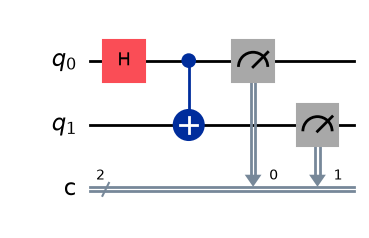

In [42]:
qc = build_bell_circuit(state)
fig = qc.draw(output="mpl", style="igp", fold=-1)
fig

## Execute de Circuit using the Quantum State 

In [43]:
backend = AerSimulator(method="statevector")
transpiled = transpile(qc, backend, optimization_level=1)
job = backend.run(transpiled, shots=1024, seed_simulator=42)
counts = job.result().get_counts()

## Plot the results

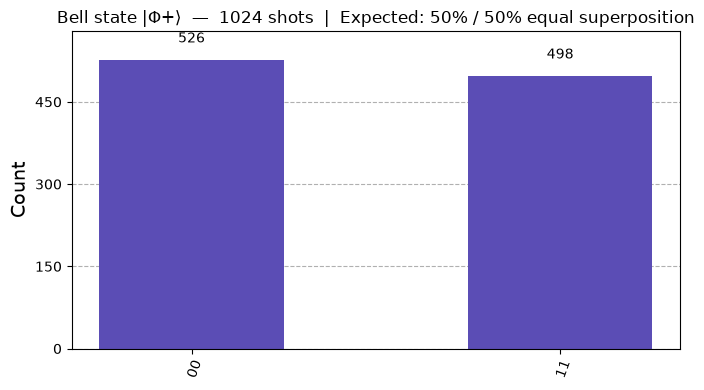

In [44]:
total = sum(counts.values())
title = (
    f"Bell state |{_latex_label(state)}⟩  —  "
    f"{total} shots  |  "
    f"Expected: 50% / 50% equal superposition"
    )
fig = plot_histogram(
    counts,
    title=title,
    bar_labels=True,
    figsize=(7, 4),
    color=["#5B4DB5", "#1D9E75"],
    )
fig.tight_layout()

fig
